Ejercicio 2

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# Ruta donde están los CSV
data_path = "Datos/."

# Patrón para localizar todos los ficheros de entrenamiento
csv_files = glob.glob(os.path.join(data_path, "TankTraining_*.csv"))
print("Encontrados:", len(csv_files), "ficheros")
print("\n".join(csv_files))

Encontrados: 25 ficheros
Datos/.\TankTraining_04_12_2025 17_27_23.csv
Datos/.\TankTraining_04_12_2025 17_28_19.csv
Datos/.\TankTraining_04_12_2025 17_28_39.csv
Datos/.\TankTraining_04_12_2025 17_28_56.csv
Datos/.\TankTraining_04_12_2025 17_29_09.csv
Datos/.\TankTraining_04_12_2025 17_29_28.csv
Datos/.\TankTraining_04_12_2025 17_29_44.csv
Datos/.\TankTraining_04_12_2025 17_29_54.csv
Datos/.\TankTraining_04_12_2025 17_30_16.csv
Datos/.\TankTraining_04_12_2025 17_30_34.csv
Datos/.\TankTraining_04_12_2025 17_30_49.csv
Datos/.\TankTraining_04_12_2025 17_31_29.csv
Datos/.\TankTraining_04_12_2025 17_31_42.csv
Datos/.\TankTraining_04_12_2025 17_31_57.csv
Datos/.\TankTraining_04_12_2025 17_32_15.csv
Datos/.\TankTraining_04_12_2025 17_32_28.csv
Datos/.\TankTraining_04_12_2025 17_39_32.csv
Datos/.\TankTraining_04_12_2025 17_39_48.csv
Datos/.\TankTraining_04_12_2025 17_40_02.csv
Datos/.\TankTraining_04_12_2025 17_40_15.csv
Datos/.\TankTraining_04_12_2025 17_57_00.csv
Datos/.\TankTraining_04_12_202

In [2]:
#array de todos los archivos
dfs = [pd.read_csv(f) for f in csv_files]
#juntarlos en uno
data = pd.concat(dfs, ignore_index=True)

print("Shape del dataset combinado:", data.shape)
data.head()

Shape del dataset combinado: (3402, 22)


,NEIGHBORHOOD_UP,NEIGHBORHOOD_DOWN,NEIGHBORHOOD_RIGHT,NEIGHBORHOOD_LEFT,NEIGHBORHOOD_DIST_UP,NEIGHBORHOOD_DIST_DOWN,NEIGHBORHOOD_DIST_RIGHT,NEIGHBORHOOD_DIST_LEFT,COMMAND_CENTER_X,COMMAND_CENTER_Y,...,AGENT_2_X,AGENT_2_Y,CAN_FIRE,HEALTH,LIFE_X,LIFE_Y,EXIT_X,EXIT_Y,time,action
0,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,19,9,23,27,0.158304,0
1,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,19,9,23,27,0.211756,0
2,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,19,9,23,27,0.302217,0
3,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,19,9,23,27,0.410886,0
4,0,1,2,1,0.0,0.307555,0.3085,8.307555,15,3,...,3.0,27.0,1,2,19,9,23,27,0.500112,0


In [3]:
#sacar el numero de acciones de cada tipo de accion
action_counts = data["action"].value_counts().sort_index()
print(action_counts)

action
0    1154
1    1271
2     155
3     545
4     277
Name: count, dtype: int64


In [4]:
# Eliminar filas donde 'action' sea NaN por si acaso
data = data.dropna(subset=["action"]).copy()

# Ahora sí podemos castear a int sin problemas
data["action_int"] = data["action"].astype(int)

#nombres de las acciones para ponerlos en la tabla
action_names = {
    0: "NOTHING",
    1: "MOVE_UP",
    2: "MOVE_DOWN",
    3: "MOVE_RIGHT",
    4: "MOVE_LEFT",
}

#columna con los nombres de las acciones
data["action_name"] = data["action_int"].map(action_names)

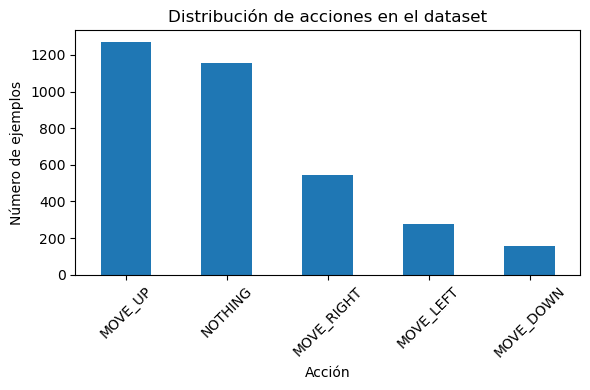

In [5]:
#hacer grafico de barras con las acciones
plt.figure(figsize=(6,4))
#cantidad de barras = acciones
action_counts = data["action_name"].value_counts()

#grafic de barras con numero de barras = numero distintas acciones
action_counts.plot(kind="bar")
plt.xlabel("Acción")
plt.ylabel("Número de ejemplos")
plt.title("Distribución de acciones en el dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features: todo menos 'action' y la columna auxiliar 'action_int'
X = data.drop(columns=["action", "action_int", "action_name"])
y = data["action_int"]
print("Shape X:", X.shape)

Shape X: (3402, 21)


In [7]:
#sacar una version normalizada de x
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
#sacar 2 componentes principales de la x normalizada
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:",
      pca.explained_variance_ratio_)

Varianza explicada por PC1 y PC2: [0.25572105 0.11862851]


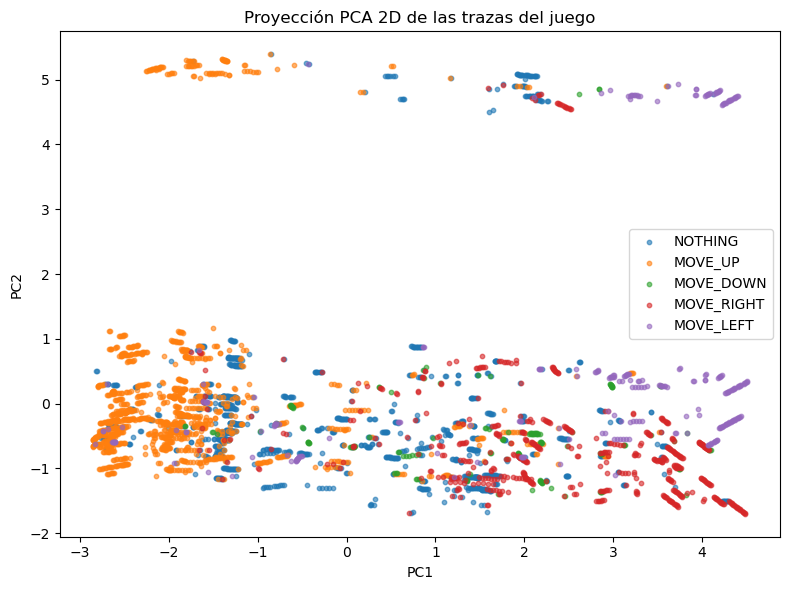

In [9]:
plt.figure(figsize=(8,6))
#pintar la grafica
for action_value, name in action_names.items():
    idx = (y == action_value)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.6,
        label=name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA 2D de las trazas del juego")
plt.legend()
plt.tight_layout()
plt.show()

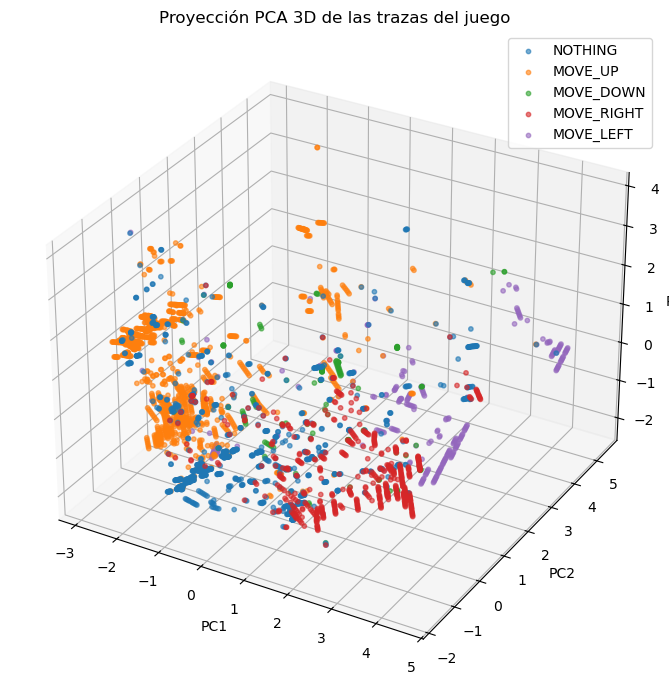

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # import necesario
#lo mismo pero con 3 componentes principales
pca3 = PCA(n_components=3, random_state=0)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for action_value, name in action_names.items():
    idx = (y == action_value)
    ax.scatter(
        X_pca3[idx, 0],
        X_pca3[idx, 1],
        X_pca3[idx, 2],
        s=10,
        alpha=0.6,
        label=name
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Proyección PCA 3D de las trazas del juego")
ax.legend()
plt.tight_layout()
plt.show()

Ejercicio 3

In [11]:
#copia del data
df = data.dropna().copy()

# Se aseguran tipos numéricos en los vecinos
for col in ["NEIGHBORHOOD_UP", "NEIGHBORHOOD_DOWN",
            "NEIGHBORHOOD_RIGHT", "NEIGHBORHOOD_LEFT"]:
    df[col] = pd.to_numeric(df[col])

# Acción como entero (0..4)
df["action_int"] = df["action"].astype(int)

In [12]:
#borrar la columna de action_name creada antes
cols_to_drop = [c for c in ["action_name"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

In [13]:
from sklearn.preprocessing import OneHotEncoder
#separar las columnas que necesitan ohe y las que no
categorical_cols = [
    "NEIGHBORHOOD_UP",
    "NEIGHBORHOOD_DOWN",
    "NEIGHBORHOOD_RIGHT",
    "NEIGHBORHOOD_LEFT",
]

# numeric_cols: todas las numéricas excepto acción y los vecinos (que van por OHE)
numeric_cols = [
    c for c in df.columns
    if c not in categorical_cols + ["action", "action_int"]
]

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['NEIGHBORHOOD_UP', 'NEIGHBORHOOD_DOWN', 'NEIGHBORHOOD_RIGHT', 'NEIGHBORHOOD_LEFT']
Numeric: ['NEIGHBORHOOD_DIST_UP', 'NEIGHBORHOOD_DIST_DOWN', 'NEIGHBORHOOD_DIST_RIGHT', 'NEIGHBORHOOD_DIST_LEFT', 'COMMAND_CENTER_X', 'COMMAND_CENTER_Y', 'AGENT_1_X', 'AGENT_1_Y', 'AGENT_2_X', 'AGENT_2_Y', 'CAN_FIRE', 'HEALTH', 'LIFE_X', 'LIFE_Y', 'EXIT_X', 'EXIT_Y', 'time']


In [14]:
#ohe de las columnas categoricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore", categories=[list(range(11))] * len(categorical_cols))
X_cat = encoder.fit_transform(df[categorical_cols])

# Numéricas como array float
X_num = df[numeric_cols].to_numpy(dtype=float)

# Dataset de entrada completo
import numpy as np
X_full = np.hstack([X_cat, X_num])

# Etiquetas
y = df["action_int"].to_numpy()
print(X_full.shape)

(3402, 61)


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.33,
    random_state=0,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train:", y_train.shape, " Test:", y_test.shape)

Train: (2279, 61)  Test: (1123, 61)
Train: (2279,)  Test: (1123,)


In [16]:
import pandas as pd
import numpy as np

# 1) Nombres de las columnas one-hot
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

# 2) DataFrames separados
X_cat_df = pd.DataFrame(X_cat, columns=cat_feature_names, index=df.index)
X_num_df = df[numeric_cols].astype(float).reset_index(drop=True)

# 3) Dataset de entrada completo como DataFrame
X_full_df = pd.concat([X_cat_df.reset_index(drop=True), X_num_df], axis=1)

print("Shape X_full_df:", X_full_df.shape)

Shape X_full_df: (3402, 61)


In [17]:
X_full = X_full_df.to_numpy()

In [18]:
#guardar el dataset limpio
df_clean = X_full_df.copy()
df_clean["action_int"] = y


df_clean.to_csv("TankTraining_clean_OHE.csv", index=False)

Ejercicio 4

In [19]:
from MLP import MLP, target_gradient, costNN, MLP_backprop_predict
from sklearn.metrics import accuracy_score

In [20]:
enc = OneHotEncoder(sparse_output=False)
YEnc =enc.fit_transform(y_train.reshape(-1,1))

In [21]:
mlp = MLP([61,100,25,5])
Jhistory = mlp.backpropagation(X_train,YEnc,1,1,2000,2000/10)
a,z= mlp.feedforward(X_test)
range =len(a)
y_pred=mlp.predict(a[range-1])
accu = accuracy_score(y_test, y_pred)
print(f"Calculate accuracy for lambda = 1 : {(accu):1.5f}")

Iteration      1: Cost   3.4315   
Iteration    201: Cost   1.2916   
Iteration    401: Cost   1.1545   
Iteration    601: Cost   1.0160   
Iteration    801: Cost   0.9782   
Iteration   1001: Cost   0.9075   
Iteration   1201: Cost   0.8703   
Iteration   1401: Cost   0.8406   
Iteration   1601: Cost   0.8162   
Iteration   1801: Cost   0.7963   
Iteration   2000: Cost   0.7816   
Calculate accuracy for lambda = 1 : 0.85396


In [22]:
mlp = MLP([61,100,25,5])
Jhistory = mlp.backpropagation(X_train,YEnc,1,0.5,2000,2000/10)
a,z= mlp.feedforward(X_test)
range =len(a)
y_pred=mlp.predict(a[range-1])
accu = accuracy_score(y_test, y_pred)
print(f"Calculate accuracy for lambda = 0.5 : {(accu):1.5f}")

Iteration      1: Cost   3.4269   
Iteration    201: Cost   1.2757   
Iteration    401: Cost   1.1258   
Iteration    601: Cost   0.9730   
Iteration    801: Cost   0.9102   
Iteration   1001: Cost   0.8500   
Iteration   1201: Cost   0.8025   
Iteration   1401: Cost   0.7631   
Iteration   1601: Cost   0.7300   
Iteration   1801: Cost   0.7019   
Iteration   2000: Cost   0.6780   
Calculate accuracy for lambda = 0.5 : 0.85485


In [23]:
mlp = MLP([61,100,25,5])
Jhistory = mlp.backpropagation(X_train,YEnc,1,0,2000,2000/10)
a,z= mlp.feedforward(X_test)
range =len(a)
y_pred=mlp.predict(a[range-1])
accu = accuracy_score(y_test, y_pred)
print(f"Calculate accuracy for lambda = 0 : {(accu):1.5f}")

Iteration      1: Cost   3.4224   
Iteration    201: Cost   1.2588   
Iteration    401: Cost   1.0933   
Iteration    601: Cost   0.9249   
Iteration    801: Cost   0.8459   
Iteration   1001: Cost   0.7681   
Iteration   1201: Cost   0.7063   
Iteration   1401: Cost   0.6544   
Iteration   1601: Cost   0.6087   
Iteration   1801: Cost   0.5687   
Iteration   2000: Cost   0.5318   
Calculate accuracy for lambda = 0 : 0.86643


MLPClassifier de SKLearn

In [24]:
from sklearn.neural_network import MLPClassifier

In [25]:
clf = MLPClassifier(hidden_layer_sizes=(100,25),activation='logistic', verbose=False , alpha= 1,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
score = clf.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 1:", score)

Accuracy de sklearn classifier con lambda = 1: 0.7399821905609973


In [26]:
clf = MLPClassifier(hidden_layer_sizes=(100,25),activation='logistic', verbose=False, alpha= 0.5,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
score = clf.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 0.5:", score)

Accuracy de sklearn classifier con lambda = 0.5: 0.8040961709706145


In [27]:
clf = MLPClassifier(hidden_layer_sizes=(100,25),activation='logistic', verbose=False, alpha= 0,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
score = clf.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 0:", score)

Accuracy de sklearn classifier con lambda = 0: 0.8673196794300979


C:\Users\diego\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


SKLearn del MLPClassifier relu

In [28]:
clfRelu = MLPClassifier(hidden_layer_sizes=(100,25),activation='relu', verbose=False , alpha= 1,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
scoreRelu = clfRelu.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 1:", score)

Accuracy de sklearn classifier con lambda = 1: 0.8673196794300979


In [29]:
clfRelu = MLPClassifier(hidden_layer_sizes=(100,25),activation='relu', verbose=False, alpha= 0.5,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
scoreRelu = clfRelu.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 0.5:", score)

Accuracy de sklearn classifier con lambda = 0.5: 0.8673196794300979


In [30]:
clfRelu = MLPClassifier(hidden_layer_sizes=(100,25),activation='relu', verbose=False, alpha= 0,random_state=0, max_iter=2000,epsilon=0.12,learning_rate_init=0.01).fit(X_train, y_train)
scoreRelu = clfRelu.score(X_test,y_test)
print("Accuracy de sklearn classifier con lambda = 0:", score)

Accuracy de sklearn classifier con lambda = 0: 0.8673196794300979


KNN

In [31]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors = 1)

model.fit(X_train, y_train)

prediction = model.predict(X_test)
print("Predicción")
print(prediction)
print("Test")
print(y_test)

model.score(X_test,y_test)

Predicción
[1 0 3 ... 4 0 2]
Test
[1 0 3 ... 4 0 0]


0.8753339269813001

 árboles de decisión

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text

desicion_tree = DecisionTreeClassifier(random_state=0, max_depth=2)

desicion_tree = desicion_tree.fit(X_train, y_train)
r = export_text(desicion_tree)
print(r)
desicion_tree.score(X_test,y_test)

|--- feature_47 <= -0.82
|   |--- feature_47 <= -0.82
|   |   |--- class: 0
|   |--- feature_47 >  -0.82
|   |   |--- class: 1
|--- feature_47 >  -0.82
|   |--- feature_47 <= 0.96
|   |   |--- class: 0
|   |--- feature_47 >  0.96
|   |   |--- class: 3



0.6999109528049866

Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

clfRF = RandomForestClassifier(max_depth=2, random_state=0)
clfRF.fit(X_train, y_train)
RandomForestClassifier(...)
print("Predicción")
print(clfRF.predict(X_test))
print("Test")
print(y_test)
clfRF.score(X_test,y_test)

Predicción
[1 0 3 ... 3 0 1]
Test
[1 0 3 ... 4 0 0]


0.7292965271593945

matriz de confusion, precision, recall y F1_score

In [34]:
from Utils import confusionMatrix, precission, recall, F1_Score

#TP,FP,TN,FN
CM = confusionMatrix(y_pred,y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[337 106]
 [ 44 636]]
Precision
0.7607223476297968
Recall
0.884514435695538
F1-score
0.8179611650485435


MLPClassifier de SKLearn

In [35]:
#TP,FP,TN,FN
CM = confusionMatrix(clf.predict(X_test),y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[324  92]
 [ 57 650]]
Precision
0.7788461538461539
Recall
0.8503937007874016
F1-score
0.8130489335006272


SKLearn del MLPClassifier relu

In [36]:
#TP,FP,TN,FN
CM = confusionMatrix(clfRelu.predict(X_test),y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[336  98]
 [ 45 644]]
Precision
0.7741935483870968
Recall
0.8818897637795275
F1-score
0.8245398773006134


KNN

In [37]:
#TP,FP,TN,FN
CM = confusionMatrix(model.predict(X_test),y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[341 100]
 [ 40 642]]
Precision
0.7732426303854876
Recall
0.89501312335958
F1-score
0.829683698296837


árboles de decisión

In [38]:
#TP,FP,TN,FN
CM = confusionMatrix(desicion_tree.predict(X_test),y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[336 292]
 [ 45 450]]
Precision
0.535031847133758
Recall
0.8818897637795275
F1-score
0.6660059464816649


Random Forest

In [39]:
#TP,FP,TN,FN
CM = confusionMatrix(clfRF.predict(X_test),y_test)
PR = precission(CM)
RC=recall(CM)
F1 = F1_Score(PR,RC)
print("Matriz de confusion")
print(CM)
print("Precision")
print(PR)
print("Recall")
print(RC)
print("F1-score")
print(F1)

Matriz de confusion
[[313 236]
 [ 68 506]]
Precision
0.5701275045537341
Recall
0.821522309711286
F1-score
0.6731182795698925


exportar MLPClassifier de SKLearn

In [40]:
from Utils import ExportAllformatsMLPSKlearn

In [42]:
ExportAllformatsMLPSKlearn(clf,X_full,"picklefile.txt","onixFile.txt","jsonFile.txt","customFile.txt")

Capa  coefficient
procesando  coefficient
['61', '100']
coefficient
[-0.06911670289409368, 0.24140113473466593, -0.011875361820897578, -0.09319230182535826, -0.07239676783049474, 0.03093077156339141, -0.5226135348148436, 0.2373519791026799, 0.04535007160554071, -0.21980963550985527, 0.21321220051375916, -0.36197206057981773, -0.38731687352516614, 0.23692346344666348, -0.3706268774585987, -0.5496037119245291, -0.3986385020331675, -0.13528548971881413, 0.2096173521754952, -0.20058214670498092, -0.2150866919362981, 0.395124783255227, -0.06880355146126996, 0.08456380089254142, -0.04090348628199163, 0.02794149457570339, -0.24096005759665468, 0.50612779334418, -0.05227634960737086, -0.05897827586270225, -0.11621064566274156, -0.19171599941115633, -0.11483736616770844, 0.6204647187025529, -0.1630126234994749, 0.1424676284291063, 0.0267081018426717, 0.15199540203866546, 0.03397638592702988, 0.36291304693671333, -0.2610398216083417, 0.22191932998886862, 0.3483058934489312, 0.11873165710842824, 